# Exercise notebook for the Wang-Landau Implemantation

## 1-Exercise
Obtain density of states $g(E)$ from the Wang-Landau sampling for system sizes L=8,12,16, for the 2D square lattice Ising model. Then plot the $\log{g(E)}\times E$.

In [1]:
include("../src/lattice.jl")
include("../src/metropolis_ising.jl")
using .UnitCell_Lattices
using .Metropolis_MonteCarlo

using Plots
using StatsBase
using StatsPlots

In [2]:
J = [1.,1.,1.]
a = 1.0
h = 0.0


0.0

In [3]:
collect(-1:2:1)

2-element Vector{Int64}:
 -1
  1

In [4]:
A = [1.0 0.0 ;
     0.0 1.0] # Lattice vectors for a square lattice
B = [0.0 ;
     0.0 ]
B = reshape(B, (2,1)) # Reshape B to be a 2x1 matrix where julia treats the single column matrices as vectors

uc_square = UnitCell(A,B)

rules = [BondRule(1,1,[1,0]), BondRule(1,1,[0,1])]

L_list = [[8,8],[16,16]]
initial_configs = []
for L in L_list
    lat = build_lattice(uc_square, rules, L)
    for site in lat.sites
        site.spin = [0,0,rand(-1:2:1)]
    end
    push!(initial_configs,lat)
end

In [5]:
log_densities = []
for c0 in initial_configs
    N = c0.num_sites
    E_spec = Float64[E for E in -2*N:4:2*N if E != 2*N-4 && E != -2*N + 4]
    g = WL_sweep(c0,E_spec,J,h)
    push!(log_densities,g)
end

Flat histogram is reached!!
0.5
Flat histogram is reached!!
0.25
Flat histogram is reached!!
0.125
Flat histogram is reached!!
0.0625
Flat histogram is reached!!
0.03125
Flat histogram is reached!!
0.015625
Flat histogram is reached!!
0.0078125
Flat histogram is reached!!
0.00390625
Flat histogram is reached!!
0.001953125
Flat histogram is reached!!
0.0009765625
Flat histogram is reached!!
0.5
Flat histogram is reached!!
0.25
Flat histogram is reached!!
0.125
Flat histogram is reached!!
0.0625
Flat histogram is reached!!
0.03125
Flat histogram is reached!!
0.015625
Flat histogram is reached!!
0.0078125
Flat histogram is reached!!
0.00390625
Flat histogram is reached!!
0.001953125
Flat histogram is reached!!
0.0009765625


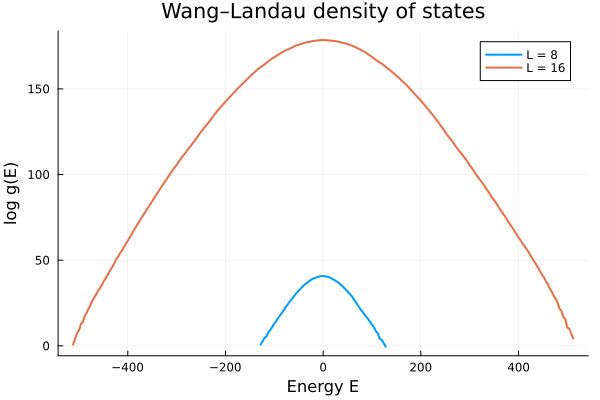

In [6]:
p = plot(
    xlabel = "Energy E",
    ylabel = "log g(E)",
    title = "Wang–Landau density of states",
    legend = :topright,
)

for (i, log_g) in enumerate(log_densities)
    N = initial_configs[i].num_sites
    E_spec = Float64[E for E in -2*N:4:2*N
                    if E != 2*N-4 && E != -2*N+4]

    # Fix the additive constant using g(E_min) = 2.
    log_g_normalized = log_g .- log_g[1] .+ log(2)

    plot!(p, E_spec, log_g_normalized;
          label = "L = $(L_list[i][1])",
          linewidth = 2)
end

display(p)

In [7]:
function normalization(log_g::Vector{Float64})
    log_g_norm = log_g .+ log(2) .- log_g[1]
    return log_g_norm
end

function log_z(T::Float64,lg_norm::Vector{Float64}, E_spec::Vector{Float64})
    beta = 1.0/T
    lz = log(sum([exp(g_e-beta*E) for (g_e,E) in zip(lg_norm,E_spec)]))
    return lz
end

function measures_dos(T::Float64,log_g::Vector{Float64},N::Int64)
    E_spec = [E for E in -2*N:4:2*N if E != 2*N-4 && E != -2*N+4]
    beta = 1.0/T

    lg_norm = normalization(log_g)
    log_weights = [lg_norm[i]-beta*E for (i,E) in enumerate(E_spec)]
    lz = log_z(T,lg_norm)
    probs = exp.(log_weights .- lz)

    m_E = sum(p*E for (p,E) in zip(probs,E_spec))
    m_E2 = sum(p*E^2 for (p,E) in zip(probs,E_spec))

    U_T = m_E/N
    Cv_T = beta^2*(m_E2-m_E^2)/N
    return U_T, Cv_T
end

measures_dos (generic function with 1 method)

In [8]:
function measures_dos(T::Float64, log_g::Vector{Float64}, N::Int)
    E_spec = Float64[E for E in -2*N:4:2*N if E != 2*N-4 && E != -2*N+4]

    beta = 1.0 / T
    log_weights = log_g .- beta .* E_spec

    # Subtract a common constant to prevent exponential overflow.
    weights = exp.(log_weights .- maximum(log_weights))
    probs = weights ./ sum(weights)

    mean_E = sum(probs .* E_spec)
    var_E = sum(probs .* (E_spec .- mean_E).^2)

    U_T = mean_E / N
    Cv_T = beta^2 * var_E / N

    return U_T, Cv_T
end

measures_dos (generic function with 1 method)

In [9]:
Temps = 0.4:0.05:4.0
data = []
for (i,log_g) in enumerate(log_densities)
    U_data = []
    Cv_data = []
    N = initial_configs[i].num_sites
    for T in Temps
        U_T, Cv_T = measures_dos(T,log_g,N)
        push!(U_data,U_T)
        push!(Cv_data,Cv_T)
    end
    push!(data,[U_data,Cv_data])
end

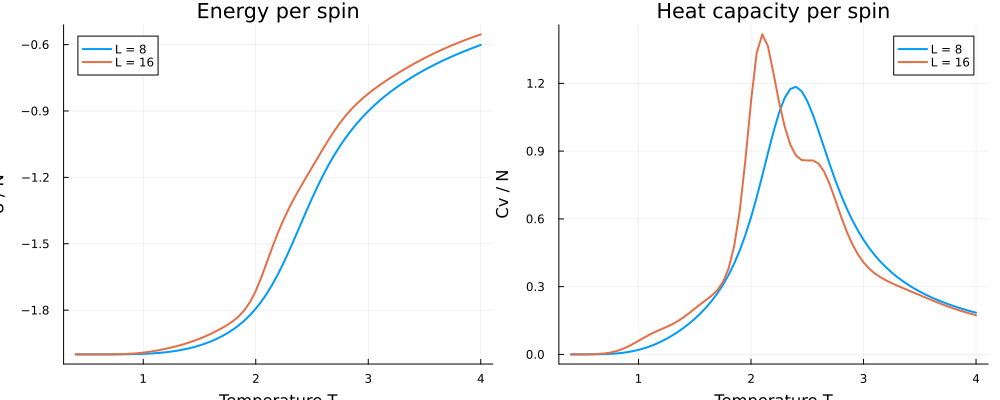

In [10]:
p_U = plot(
    xlabel = "Temperature T",
    ylabel = "U / N",
    title = "Energy per spin",
    legend = :topleft,
)

p_Cv = plot(
    xlabel = "Temperature T",
    ylabel = "Cv / N",
    title = "Heat capacity per spin",
    legend = :topright,
)

for (i, L) in enumerate(L_list)
    U_data, Cv_data = data[i]
    label = "L = $(L[1])"

    plot!(p_U, Temps, U_data; label, linewidth = 2)
    plot!(p_Cv, Temps, Cv_data; label, linewidth = 2)
end

plot(p_U, p_Cv; layout = (1, 2), size = (1000, 400))